In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
torch.set_default_dtype(torch.float64)

import os
import sys

# Add parent directory to path (notebook-friendly approach)
notebook_dir = os.getcwd()
if notebook_dir.endswith('notebooks'):
    parent_dir = os.path.dirname(notebook_dir)
    sys.path.insert(0, parent_dir)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import itertools
from utils.utils import load_data
from omegaconf import OmegaConf
import wandb
from constants import MODELNAME_TO_CLASS
from matplotlib.patches import Patch
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Many Obstacle CBF Visualization

In [3]:
# Load the CBF dataset
dataset_cfg = {
    'prob_type': 'cbf',
    'n_examples': 1000,
    'num_var': 2,
    'num_eq': 0,
    'num_ineq': 3,
    'seed': 8,
}
# Convert dict to OmegaConf DictConfig
dataset_cfg = OmegaConf.create(dataset_cfg)

data = load_data(dataset_cfg, device=DEVICE)

cbf_dataset_path = os.path.join('datasets', 'cbf', 'cbf_var2_ineq3_eq0_seed8')

Loading dataset from: /home/aboukas/hard-constrain/datasets/cbf/cbf_var2_ineq3_eq0_seed8


In [4]:
# Load DC3 trained model from wandb 
workspace = "ConstrainedNN"  # Replace with your wandb entity
WANDB_PROJECT = "cbf_base_comparison_mar15"  # Replace with your project name
WANDB_RUN_NAME = "seed123_dc3_trainCorr10_testCorr0_corrLr1e-13_corrEps0.0001"  # Replace with the run name

# Initialize wandb API
api = wandb.Api()

run_path = f"{workspace}/{WANDB_PROJECT}" 
runs = api.runs(run_path)
run = runs[0]  # Assuming you want the first run; modify as needed

# Load config directly from wandb run
config = OmegaConf.create(dict(run.config))

# Construct artifact path: project/artifact_name:version
artifact_path = f"{workspace}/{WANDB_PROJECT}/{WANDB_RUN_NAME}:v1"

try:
    artifact = api.artifact(artifact_path, type='model')
    artifact_dir = artifact.download()
    
    # Load model architecture
    model_name = config.model.name
    model_class = MODELNAME_TO_CLASS.get(model_name, None)
    if model_class is None:
        raise ValueError(f"Unknown model name: {model_name}")
    
    trained_model_dc = model_class(data, config)
    trained_model_dc.to(DEVICE)
    
    # Load model weights
    model_path = os.path.join(artifact_dir, 'net.dict')
    trained_model_dc.load_state_dict(torch.load(model_path, map_location=DEVICE))
    trained_model_dc.eval()
    
    print(f" Model loaded successfully from: {model_path}")
    print(f"  Model name: {model_name}")
    
except Exception as e:
    print(f"Error loading model from wandb: {e}")
    print(f"Attempted to load from: {artifact_path}")
    raise

wandb:   1 of 1 files downloaded.  


 Model loaded successfully from: /home/aboukas/hard-constrain/notebooks/artifacts/seed123_dc3_trainCorr10_testCorr0_corrLr1e-13_corrEps0.0001:v1/net.dict
  Model name: dc3


In [5]:
# Load SnareNet trained model from wandb
workspace = "ConstrainedNN"  # Replace with your wandb entity
WANDB_PROJECT = "cbf_base_comparison_mar12"  # Replace with your project name
WANDB_RUN_NAME = "seed123_snarenet_pinv_lambda0.01_rtol1e-06_soft50"  # Replace with the run name

# Initialize wandb API
api = wandb.Api()

# Get the run to access its config
run_path = f"{workspace}/{WANDB_PROJECT}" 
runs = api.runs(run_path)
run = runs[0]  # Assuming you want the first run; modify as needed

# Load config directly from wandb run
config = OmegaConf.create(dict(run.config))
# print(config.model)

# Construct artifact path: project/artifact_name:version
artifact_path = f"{workspace}/{WANDB_PROJECT}/{WANDB_RUN_NAME}:v0"

print(f"Downloading model from wandb artifact: {artifact_path}")
try:
    artifact = api.artifact(artifact_path, type='model')
    artifact_dir = artifact.download()
    
    # Load model architecture
    model_name = "snarenet"
    model_class = MODELNAME_TO_CLASS.get(model_name, None)
    if model_class is None:
        raise ValueError(f"Unknown model name: {model_name}")
    
    trained_model_sn = model_class(data, config)
    trained_model_sn.to(DEVICE)
    
    # Load model weights
    model_path = os.path.join(artifact_dir, 'net.dict')
    trained_model_sn.load_state_dict(torch.load(model_path, map_location=DEVICE))
    trained_model_sn.eval()
    
    print(f" Model loaded successfully from: {model_path}")
    print(f"  Model name: {model_name}")
    
except Exception as e:
    print(f"Error loading model from wandb: {e}")
    print(f"Attempted to load from: {artifact_path}")
    raise

wandb:   1 of 1 files downloaded.  


 Model loaded successfully from: /home/aboukas/hard-constrain/notebooks/artifacts/seed123_snarenet_pinv_lambda0.01_rtol1e-06_soft50:v0/net.dict
  Model name: snarenet


In [14]:
matplotlib.rcParams['text.usetex'] = True
plt.style.use('seaborn-v0_8-whitegrid')

def simulate_policies(data, init_state, cost_fn, policy_list, label_list, color_list, linestyle_list, nstep=None, dt=None):
    """
    Plot the trajectories given policies.
    """
    fig = plt.figure(figsize=(4, 4))

    ## plot init_box (yellow shaded region)
    if hasattr(data._sys, '_init_box'):
        init_box = data._sys._init_box
        x_min, y_min = init_box[0][0], init_box[0][1]
        x_max, y_max = init_box[1][0], init_box[1][1]
        width = x_max - x_min
        height = y_max - y_min
        from matplotlib.patches import Rectangle
        rect = Rectangle((x_min, y_min), width, height, 
                         color='yellow', fill=True, alpha=0.3, 
                         label='Initial region')
        plt.gca().add_artist(rect)
    
    ## plot obstacles
    for obs in data.obs_list:
        ellipse = Ellipse((obs.cx, obs.cy), width=2*obs.rx, height=2*obs.ry, angle=0, facecolor='grey', fill=True, linestyle='-', linewidth=2, alpha=0.5, edgecolor='black')
        plt.gca().add_artist(ellipse)

    for policy, label, c, ls in zip(policy_list, label_list, color_list, linestyle_list):
        policy.eval()
        if label == 'Nominal Control':
            cost, traj = data.run_episode(policy, init_state, cost_fn, nstep=2*nstep, dt=dt, saveTraj=True)
        else: 
            cost, traj = data.run_episode(policy, init_state, cost_fn, nstep=nstep, dt=dt, saveTraj=True)
        center_traj = data.sys.get_center(traj[:,0,:]).detach().cpu().numpy()
        cost_value = cost[0].detach().item() if torch.is_tensor(cost[0]) else cost[0]
        plt.plot(center_traj[:,0], center_traj[:,1], ls, color=c, label=label+' (%.2f)'%cost_value, markersize=2, alpha=0.5)
    
    # plot start and goal point
    plt.scatter(center_traj[0,0], center_traj[0,1], s=100, color="k", facecolor="none", alpha=0.75, label="Initial position")
    plt.scatter(0.0, 0.0, s=200, color="purple", marker='*', alpha=0.75, label="Goal")

    plt.xlabel('$p_x$')
    plt.ylabel('$p_y$')
    plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlim([-10,2])
    plt.ylim([-2,10])
    plt.show()

    return fig

def create_legend_figure(policy_list, label_list, color_list, linestyle_list):
    # Create a temporary figure to generate legend handles
    temp_fig, temp_ax = plt.subplots()
    
    # Collect policy handles first
    policy_dict = {}
    
    for _, label, c, ls in zip(policy_list, label_list, color_list, linestyle_list):        
        # Create line handle with the appropriate style
        line, = temp_ax.plot([], [], ls, color=c, markersize=4, alpha=0.5)
        policy_dict[label] = line
    
    # Define top row and bottom row items in order
    # Top row: Initial region, goal, Initial position
    # Bottom row: Nominal Control, DC3, SnareNet
    
    init_box_patch = Patch(color='yellow', alpha=0.3, label='Initial region')
    goal_marker = temp_ax.scatter([], [], s=200, color="purple", marker='*', alpha=0.75)
    init_marker = temp_ax.scatter([], [], s=100, color="k", facecolor="none", alpha=0.75)
    
    top_row = [
        (init_box_patch, 'Initial region'),
        (goal_marker, 'Goal'),
        (init_marker, 'Initial position')
    ]
    
    bottom_row = [
        (policy_dict.get('Nominal Control'), 'Nominal Control'),
        (policy_dict.get('DC3'), 'DC3'),
        (policy_dict.get('SnareNet'), 'SnareNet')
    ]
    
    # Matplotlib's ncol fills column-wise, so we need to interleave:
    # [col1_row1, col1_row2, col2_row1, col2_row2, col3_row1, col3_row2]
    handles = []
    labels = []
    for i in range(len(top_row)):
        if top_row[i][0] is not None:
            handles.append(top_row[i][0])
            labels.append(top_row[i][1])
        if i < len(bottom_row) and bottom_row[i][0] is not None:
            handles.append(bottom_row[i][0])
            labels.append(bottom_row[i][1])
    
    plt.close(temp_fig)
    
    # Create the actual legend figure with minimal whitespace
    legend_fig = plt.figure(figsize=(8, 1.5))
    legend_ax = legend_fig.add_subplot(111)
    legend_ax.axis('off')
    
    # Create the legend with ncol=3 to get 2 rows
    legend = legend_ax.legend(handles, labels, loc='center', ncol=3, 
                             frameon=True, fontsize=12, 
                             handlelength=2.5, handleheight=1.5,
                             borderaxespad=0)
    
    # Remove all whitespace and margins
    legend_fig.tight_layout(pad=0)
    legend_fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    
    # Get the legend bounding box and adjust figure size to fit exactly
    bbox = legend.get_window_extent(legend_fig.canvas.get_renderer())
    bbox = bbox.transformed(legend_fig.dpi_scale_trans.inverted())
    legend_fig.set_size_inches(bbox.width, bbox.height)
    
    plt.show()
    
    return legend_fig

In [7]:
# Wrapper class to make functions compatible with module interface
class FunctionWrapper(nn.Module):
    """Wraps a function to behave like a neural network module"""
    def __init__(self, fn):
        super().__init__()
        self.fn = fn
    
    def forward(self, x):
        return self.fn(x)

# Set up policy list
policy_list = []
label_list = []

policy_list.append(trained_model_sn)
label_list.append('SnareNet')

policy_list.append(trained_model_dc)
label_list.append('DC3')

policy_list.append(FunctionWrapper(data.get_nominal_control))
label_list.append('Nominal Control')

print(f"Set up {len(policy_list)} policies for discrete_cbf visualization")

Set up 3 policies for discrete_cbf visualization


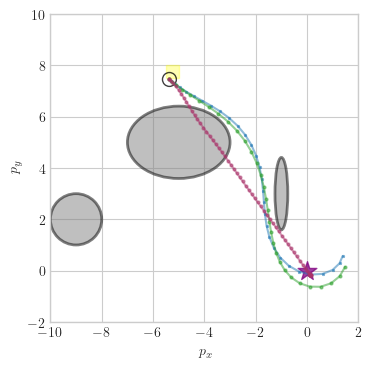

In [23]:
tableau10 = [(31, 119, 180), (44, 160, 44), (170, 51, 106), (227, 119, 194)]
for i in range(len(tableau10)):
    r, g, b = tableau10[i]
    tableau10[i] = (r / 255., g / 255., b / 255.)

dt, nstep = 0.04, 30
np.random.seed(8)
init_state = torch.tensor(data._sys.generate_states(1), device=DEVICE)

linestyle_list = ['-*' if 'SnareNet' in label else '-o' for label in label_list]

cost_fn = data.evaluate
fig = simulate_policies(data, init_state, cost_fn, policy_list, label_list, tableau10, linestyle_list, nstep, dt)
fig.savefig('../figures/final_3_obs_cbf.pdf',dpi=300, bbox_inches='tight')

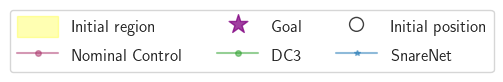

In [9]:
# Generate separate legend figure
legend_fig = create_legend_figure(policy_list, label_list, tableau10, linestyle_list)
legend_fig.savefig('../figures/final_3_obs_cbf_legend.pdf', dpi=300, bbox_inches='tight')